<a href="https://colab.research.google.com/github/archanadby05/Neural_Network_from_Scratch/blob/master/activation-functions/01_step_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step Function and Perceptron for AND Gate


### 01. Define Step Function

We implement the binary step function, a threshold-based activation used in early perceptrons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def step_function(x):
    return np.where(x >= 0, 1, 0)

*Explanation:*

The step function outputs 1 if input is ≥ 0, otherwise 0. It introduces non-linearity but is not differentiable, making it incompatible with gradient-based training.

### 02. Create AND Dataset

We define the dataset for the logical AND operation.

In [2]:
# Input and expected output for AND gate
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])
print("Entradas P:", X)  # Matrix P [4x2]

y = np.array([0, 0, 0, 1])  # vector [1x4]
print("Target:", y)

Entradas P: [[0 0]
 [0 1]
 [1 0]
 [1 1]]
Target: [0 0 0 1]


*Explanation:*

This dataset represents the AND logic gate, where the output is 1 only if both inputs are 1.

### 03. Train Perceptron (Manual Weights)

We manually train a perceptron using the step function activation.

In [3]:
# Initialize weights and bias
W = np.array([1.0, 1.0])
b = -1.5
print("W:", W)  # Pesos sinapticos W[1x2]
def perceptron(X):
    return step_function(np.dot(X, W) + b)

predictions = perceptron(X)
print("Predictions:", predictions)

W: [1. 1.]
Predictions: [0 0 0 1]


*Explanation:*

Using weights [1.0, 1.0] and bias -1.5 works for the AND gate. Since the step function is non-differentiable, no gradient-based updates are used here.

### 04. Visualize Decision Boundary

We plot the decision surface created by this simple perceptron.

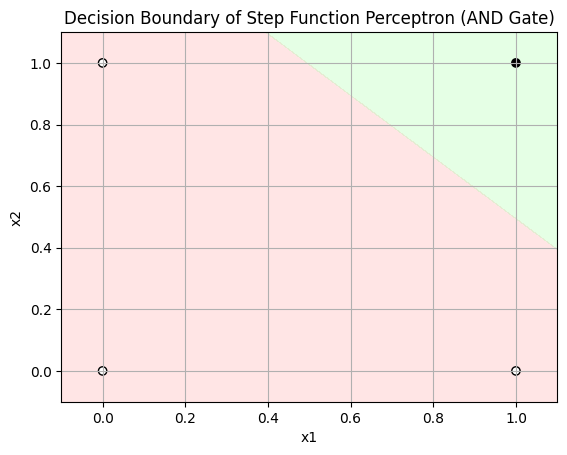

In [4]:
# Plotting decision boundary
x_min, x_max = -0.1, 1.1
y_min, y_max = -0.1, 1.1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = perceptron(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, levels=[-1, 0, 1], colors=["#FFAAAA", "#AAFFAA"])
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.binary)
plt.title("Decision Boundary of Step Function Perceptron (AND Gate)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

*Explanation:*

This plot shows how the perceptron splits input space into 0s and 1s using a linear decision boundary.

### 05. Why Not Suitable for Gradient Descent?

The step function's derivative is zero almost everywhere and undefined at 0, making it impossible to compute meaningful gradients. Thus, it's not used in modern neural networks trained with backpropagation.

